# NFL Win Total Monte Carlo Simulator - 2025 Season

**Method:** Each team's strength is their net scoring margin per game. Win probability uses a logistic function of the strength differential plus home-field advantage. We run 10,000 simulated seasons and compare simulated distributions against both the preseason betting market lines and actual final records.

**Why this season is interesting:** Seattle (60-1 preseason) and New England (80-1) met in Super Bowl LX. Kansas City, an 11.5-win favorite, finished 6-11. Three teams tied for the best record at 14-3. The 2025 season was one of the biggest upsets of preseason expectations in recent NFL history.

**Data:** Final 2025 regular season records and PPG stats (all 32 teams). Preseason win totals from ESPN Bet.

---


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.special import expit
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print("Libraries loaded.")


Libraries loaded.


## 1. Team data

Two inputs per team:
- **PPG stats** from the 2025 final regular season — used to compute strength ratings for the simulation
- **Preseason O/U line** from ESPN Bet — used as a benchmark to see how the market fared vs reality

Strength: `ppg_for - ppg_against`


In [2]:
# 2025 NFL final regular season stats
# Source: champsorchumps.us/summary/nfl/2025
# ESPN Bet preseason win totals from espn.com/espn/betting (March 2025)
# Format: (team, conference, division, actual_wins, ppg_for, ppg_against, espnbet_ou)
# Note: Green Bay went 9-7-1; Dallas went 7-9-1 — counted as 9 and 7 respectively

team_data = [
    # AFC East
    ("New England Patriots",   "AFC", "East",  14, 28.8, 18.8,  5.5),
    ("Buffalo Bills",          "AFC", "East",  12, 28.3, 21.5, 11.5),
    ("Miami Dolphins",         "AFC", "East",   7, 20.4, 24.9,  8.5),
    ("New York Jets",          "AFC", "East",   3, 17.6, 29.6,  6.5),
    # AFC North
    ("Pittsburgh Steelers",    "AFC", "North", 10, 23.4, 22.8,  8.5),
    ("Baltimore Ravens",       "AFC", "North",  8, 24.9, 23.4, 11.5),
    ("Cincinnati Bengals",     "AFC", "North",  6, 24.4, 28.9, 10.5),
    ("Cleveland Browns",       "AFC", "North",  5, 16.4, 22.3,  4.5),
    # AFC South
    ("Jacksonville Jaguars",   "AFC", "South", 13, 27.9, 19.8,  7.5),
    ("Houston Texans",         "AFC", "South", 12, 23.8, 17.4, 10.5),
    ("Indianapolis Colts",     "AFC", "South",  8, 27.4, 24.2,  8.5),
    ("Tennessee Titans",       "AFC", "South",  3, 16.7, 28.1,  5.5),
    # AFC West
    ("Denver Broncos",         "AFC", "West",  14, 23.6, 18.3, 10.5),
    ("Los Angeles Chargers",   "AFC", "West",  11, 21.6, 20.0, 10.5),
    ("Kansas City Chiefs",     "AFC", "West",   6, 21.3, 19.3, 11.5),
    ("Las Vegas Raiders",      "AFC", "West",   3, 14.2, 25.4,  5.5),
    # NFC East
    ("Philadelphia Eagles",    "NFC", "East",  11, 22.3, 19.1, 11.5),
    ("Dallas Cowboys",         "NFC", "East",   7, 27.7, 30.1,  7.5),
    ("Washington Commanders",  "NFC", "East",   5, 20.9, 26.5,  9.5),
    ("New York Giants",        "NFC", "East",   4, 22.4, 25.8,  5.5),
    # NFC North
    ("Chicago Bears",          "NFC", "North", 11, 25.9, 24.4,  8.5),
    ("Detroit Lions",          "NFC", "North",  9, 28.3, 24.3, 10.5),
    ("Green Bay Packers",      "NFC", "North",  9, 23.0, 21.2,  9.5),
    ("Minnesota Vikings",      "NFC", "North",  9, 20.2, 19.6,  8.5),
    # NFC South
    ("Carolina Panthers",      "NFC", "South",  8, 18.3, 22.4,  6.5),
    ("Atlanta Falcons",        "NFC", "South",  8, 20.8, 23.6,  8.5),
    ("Tampa Bay Buccaneers",   "NFC", "South",  8, 22.4, 24.2,  9.5),
    ("New Orleans Saints",     "NFC", "South",  6, 18.0, 22.5,  5.5),
    # NFC West
    ("Seattle Seahawks",       "NFC", "West",  14, 28.4, 17.2,  6.5),
    ("Los Angeles Rams",       "NFC", "West",  12, 30.5, 20.4, 10.5),
    ("San Francisco 49ers",    "NFC", "West",  12, 25.7, 21.8, 10.5),
    ("Arizona Cardinals",      "NFC", "West",   3, 20.9, 28.7,  8.5),
]

df = pd.DataFrame(team_data, columns=[
    "team", "conference", "division", "actual_wins",
    "ppg_for", "ppg_against", "ou_line"
])
df["strength"] = df["ppg_for"] - df["ppg_against"]
df["div_full"]  = df["conference"] + "_" + df["division"]

print(df[["team","conference","division","actual_wins","ppg_for","ppg_against","strength","ou_line"]]
      .sort_values("strength", ascending=False)
      .to_string(index=False))


                 team conference division  actual_wins  ppg_for  ppg_against  strength  ou_line
     Seattle Seahawks        NFC     West           14     28.4         17.2      11.2      6.5
     Los Angeles Rams        NFC     West           12     30.5         20.4      10.1     10.5
 New England Patriots        AFC     East           14     28.8         18.8      10.0      5.5
 Jacksonville Jaguars        AFC    South           13     27.9         19.8       8.1      7.5
        Buffalo Bills        AFC     East           12     28.3         21.5       6.8     11.5
       Houston Texans        AFC    South           12     23.8         17.4       6.4     10.5
       Denver Broncos        AFC     West           14     23.6         18.3       5.3     10.5
        Detroit Lions        NFC    North            9     28.3         24.3       4.0     10.5
  San Francisco 49ers        NFC     West           12     25.7         21.8       3.9     10.5
   Indianapolis Colts        AFC    Sout

## 2. Win probability model

`P(home wins) = sigmoid(k * (strength_home - strength_away + HFA))`

- `k = 0.12` logistic scaling factor
- `HFA = 2.5` home-field advantage in PPG-equivalent points

> **Important framing:** This simulation uses *final season* PPG stats as its strength input. That means it reflects how good teams *turned out to be*, not how good the preseason market thought they'd be. Comparing simulated win distributions against the ESPN Bet O/U lines shows how much the market misjudged team quality heading into 2025.


In [3]:
K   = 0.12
HFA = 2.5

strength_map = dict(zip(df["team"], df["strength"]))

def win_prob(home: str, away: str) -> float:
    diff = strength_map[home] - strength_map[away] + HFA
    return float(expit(K * diff))

def simulate_season(schedule: list) -> dict:
    wins = defaultdict(int)
    for home, away in schedule:
        if np.random.random() < win_prob(home, away):
            wins[home] += 1
        else:
            wins[away] += 1
    return wins

# Sanity checks
print(f"SEA (home) vs NE:   SEA win prob = {win_prob('Seattle Seahawks','New England Patriots'):.3f}")
print(f"NE (home) vs SEA:    NE win prob = {win_prob('New England Patriots','Seattle Seahawks'):.3f}")
print(f"KC (home) vs TEN:    KC win prob = {win_prob('Kansas City Chiefs','Tennessee Titans'):.3f}")
print(f"Two equal teams (home):           = {expit(K * HFA):.3f}")


SEA (home) vs NE:   SEA win prob = 0.609
NE (home) vs SEA:    NE win prob = 0.539
KC (home) vs TEN:    KC win prob = 0.871
Two equal teams (home):           = 0.574


## 3. Schedule construction

Same verified structure as the 2024 notebook:
- 6 games vs division opponents (home + away)
- 4 games vs one full same-conference division
- 4 games vs one full cross-conference division
- 2 rank-based same-conference games
- 1 rank-based cross-conference game

Total: **17 games per team**, verified.


In [4]:
TD = df.groupby("div_full")["team"].apply(list).to_dict()

schedule = []

def full_cross(d1, d2):
    for i, t1 in enumerate(d1):
        for j, t2 in enumerate(d2):
            if (i + j) % 2 == 0:
                schedule.append((t1, t2))
            else:
                schedule.append((t2, t1))

# Division games (H+A)
for members in TD.values():
    for i in range(4):
        for j in range(i+1, 4):
            schedule.append((members[i], members[j]))
            schedule.append((members[j], members[i]))

# Same-conf cross-division (4 games)
full_cross(TD["AFC_East"],  TD["AFC_North"])
full_cross(TD["AFC_South"], TD["AFC_West"])
full_cross(TD["NFC_East"],  TD["NFC_North"])
full_cross(TD["NFC_South"], TD["NFC_West"])

# Cross-conf (4 games)
full_cross(TD["AFC_East"],  TD["NFC_East"])
full_cross(TD["AFC_North"], TD["NFC_North"])
full_cross(TD["AFC_South"], TD["NFC_West"])
full_cross(TD["AFC_West"],  TD["NFC_South"])

# Rank-based same-conf (2 per team)
for pos in range(4):
    h = pos % 2 == 0
    def g(t1, t2, home): return (t1, t2) if home else (t2, t1)
    schedule.append(g(TD["AFC_East"][pos],  TD["AFC_South"][pos], h))
    schedule.append(g(TD["AFC_East"][pos],  TD["AFC_West"][pos],  not h))
    schedule.append(g(TD["AFC_North"][pos], TD["AFC_South"][pos], not h))
    schedule.append(g(TD["AFC_North"][pos], TD["AFC_West"][pos],  h))
    schedule.append(g(TD["NFC_East"][pos],  TD["NFC_South"][pos], h))
    schedule.append(g(TD["NFC_East"][pos],  TD["NFC_West"][pos],  not h))
    schedule.append(g(TD["NFC_North"][pos], TD["NFC_South"][pos], not h))
    schedule.append(g(TD["NFC_North"][pos], TD["NFC_West"][pos],  h))

# Rank-based cross-conf (1 per team)
for pos in range(4):
    h = pos % 2 == 0
    schedule.append(g(TD["AFC_East"][pos],  TD["NFC_West"][pos],  h))
    schedule.append(g(TD["AFC_North"][pos], TD["NFC_South"][pos], not h))
    schedule.append(g(TD["AFC_South"][pos], TD["NFC_North"][pos], h))
    schedule.append(g(TD["AFC_West"][pos],  TD["NFC_East"][pos],  not h))

counts = Counter()
for home, away in schedule:
    counts[home] += 1
    counts[away] += 1

print(f"Total games:        {len(schedule)}")
print(f"Games per team:     {sorted(set(counts.values()))}")
print(f"All teams 17 games: {all(c == 17 for c in counts.values())}")


Total games:        272
Games per team:     [17]
All teams 17 games: True


## 4. Run 10,000 season simulations


In [5]:
N_SIMS = 10_000
all_teams = df["team"].tolist()
sim_wins = {team: [] for team in all_teams}

for _ in range(N_SIMS):
    result = simulate_season(schedule)
    for team in all_teams:
        sim_wins[team].append(result.get(team, 0))

summary_rows = []
for team in all_teams:
    wins = np.array(sim_wins[team])
    row  = df[df.team == team].iloc[0]
    summary_rows.append({
        "team":        team,
        "conference":  row.conference,
        "division":    row.division,
        "div_full":    row.div_full,
        "actual_wins": int(row.actual_wins),
        "ou_line":     row.ou_line,
        "sim_mean":    wins.mean(),
        "sim_std":     wins.std(),
        "p10":         np.percentile(wins, 10),
        "p90":         np.percentile(wins, 90),
        "p_10plus":    (wins >= 10).mean(),
        "p_12plus":    (wins >= 12).mean(),
    })

df_summary = (pd.DataFrame(summary_rows)
              .sort_values("sim_mean", ascending=False)
              .reset_index(drop=True))
df_summary["market_diff"] = df_summary["actual_wins"] - df_summary["ou_line"]

print(f"Simulations: {N_SIMS:,}\n")
print(df_summary[["team","actual_wins","ou_line","sim_mean","sim_std"]]
      .to_string(index=False, float_format="%.1f"))


Simulations: 10,000

                 team  actual_wins  ou_line  sim_mean  sim_std
 New England Patriots           14      5.5      12.9      1.7
     Seattle Seahawks           14      6.5      12.4      1.7
     Los Angeles Rams           12     10.5      12.4      1.7
        Buffalo Bills           12     11.5      11.6      1.8
 Jacksonville Jaguars           13      7.5      11.4      1.8
       Denver Broncos           14     10.5      10.9      1.9
        Detroit Lions            9     10.5      10.3      1.9
       Houston Texans           12     10.5      10.3      1.9
   Kansas City Chiefs            6     11.5      10.1      1.9
  Philadelphia Eagles           11     11.5      10.1      1.9
  San Francisco 49ers           12     10.5       9.7      1.8
   Indianapolis Colts            8      8.5       9.5      1.9
    Minnesota Vikings            9      8.5       9.5      2.0
 Los Angeles Chargers           11     10.5       9.5      1.9
     Baltimore Ravens            8

## 5. Three-way comparison: simulated vs market vs actual

The most useful view for 2025 — placing each team's actual wins against both what the betting market expected and what the PPG-based simulation projected retroactively.


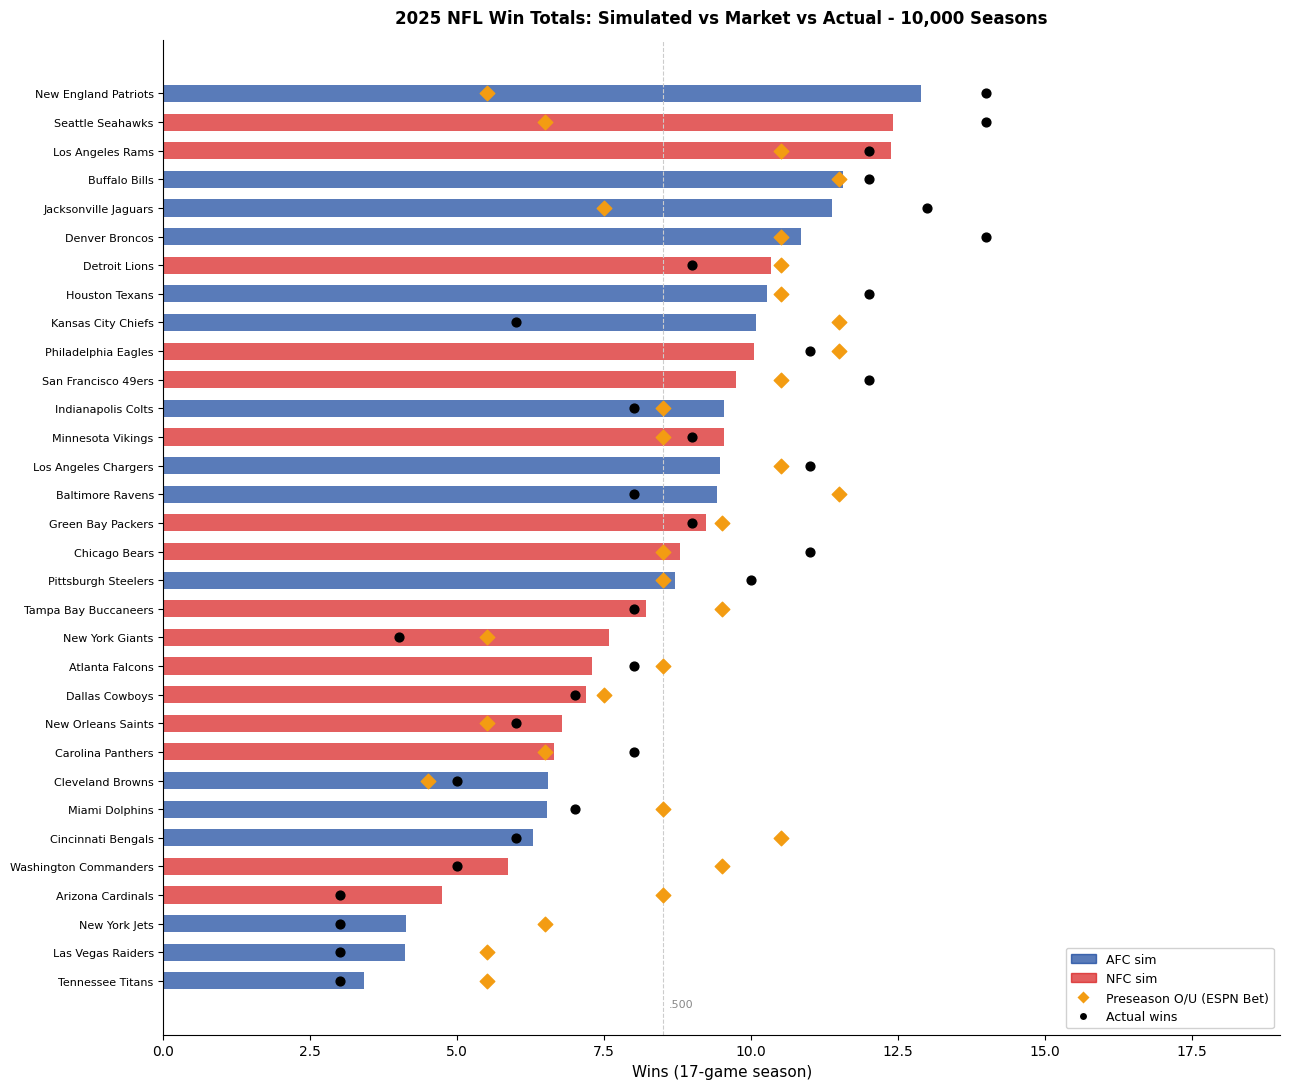

Saved: nfl_win_totals_2025.png


In [6]:
df_plot = df_summary.sort_values("sim_mean", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(13, 11))

y_pos  = range(len(df_plot))
colors = ["#003594" if c == "AFC" else "#D50A0A" for c in df_plot["conference"]]

# Simulated mean bars
ax.barh(list(y_pos), df_plot["sim_mean"],
        color=colors, alpha=0.65, height=0.6, label="Simulated mean (PPG-based)")

# Preseason O/U line as diamond
ax.scatter(df_plot["ou_line"], list(y_pos),
           color="#f39c12", s=55, zorder=5, marker="D", label="ESPN Bet preseason O/U")

# Actual wins as dot
ax.scatter(df_plot["actual_wins"], list(y_pos),
           color="black", s=40, zorder=6, label="Actual 2025 wins")

ax.set_yticks(list(y_pos))
ax.set_yticklabels(df_plot["team"], fontsize=8)
ax.set_xlabel("Wins (17-game season)", fontsize=11)
ax.set_title(
    f"2025 NFL Win Totals: Simulated vs Market vs Actual - {N_SIMS:,} Seasons",
    fontsize=12, fontweight="bold", pad=12
)
ax.set_xlim(0, 19)
ax.axvline(8.5, color="#cccccc", linestyle="--", linewidth=0.8)
ax.text(8.6, -0.9, ".500", fontsize=8, color="#888888")

afc_p  = mpatches.Patch(color="#003594", alpha=0.65, label="AFC sim")
nfc_p  = mpatches.Patch(color="#D50A0A", alpha=0.65, label="NFC sim")
ou_m   = plt.Line2D([0],[0], marker='D', color='w', markerfacecolor='#f39c12',
                     markersize=7, label="Preseason O/U (ESPN Bet)")
act_d  = plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='black',
                     markersize=6, label="Actual wins")
ax.legend(handles=[afc_p, nfc_p, ou_m, act_d], loc="lower right", fontsize=9, framealpha=0.9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("nfl_win_totals_2025.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: nfl_win_totals_2025.png")


## 6. The biggest upsets: market vs actual

The 2025 season was defined by teams massively outperforming and underperforming their preseason lines. This chart ranks all 32 teams by how far their actual wins deviated from the ESPN Bet O/U.


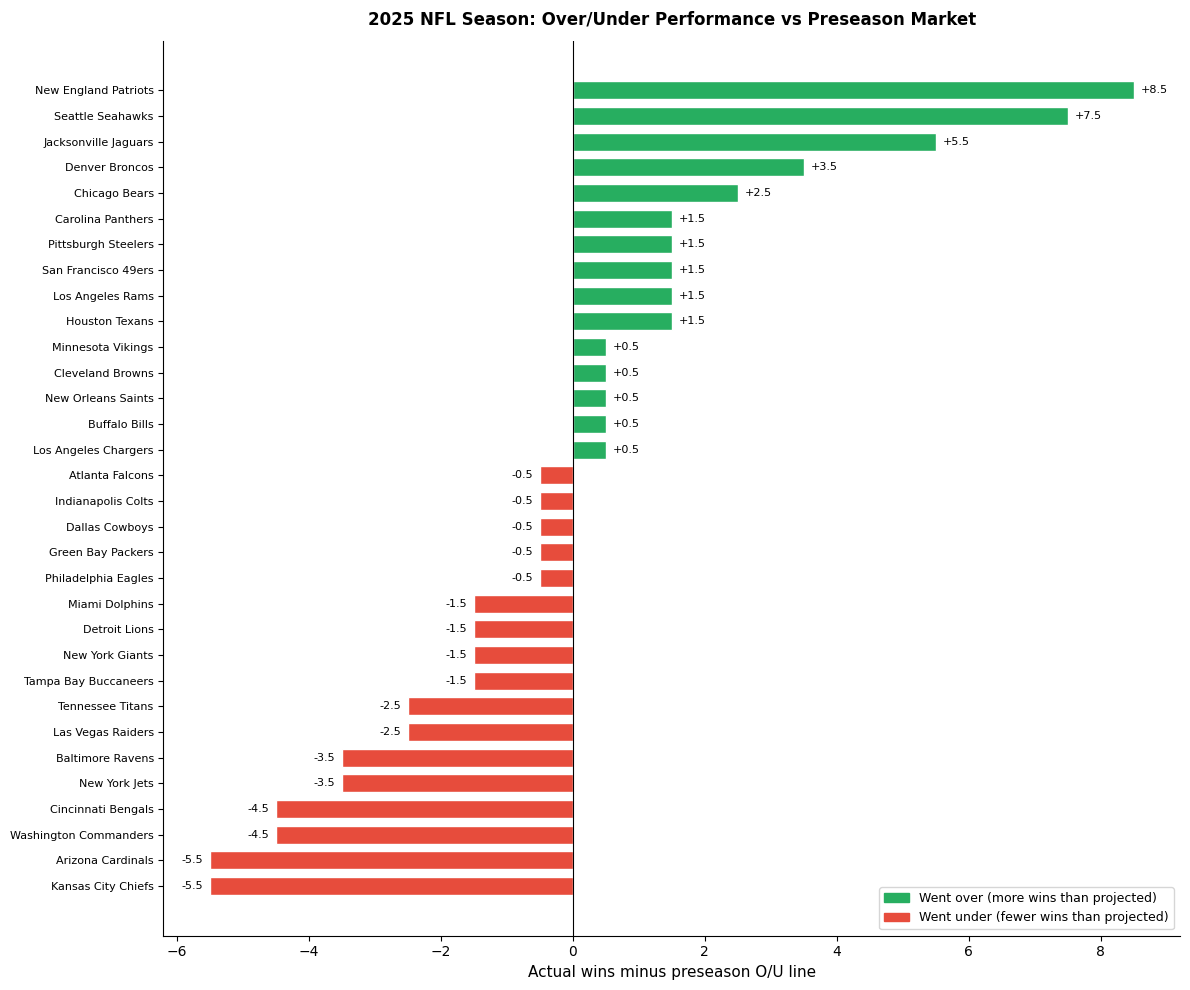

Saved: nfl_market_vs_actual_2025.png


In [7]:
df_upset = df_summary.copy()
df_upset["market_diff"] = df_upset["actual_wins"] - df_upset["ou_line"]
df_upset = df_upset.sort_values("market_diff", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 10))

y_pos   = range(len(df_upset))
bar_col = ["#27ae60" if d >= 0 else "#e74c3c" for d in df_upset["market_diff"]]
bars    = ax.barh(list(y_pos), df_upset["market_diff"],
                  color=bar_col, edgecolor="white", height=0.7)

for bar, val, team in zip(bars, df_upset["market_diff"], df_upset["team"]):
    lbl = f"+{val:.1f}" if val >= 0 else f"{val:.1f}"
    xpos = bar.get_width() + 0.1 if val >= 0 else bar.get_width() - 0.1
    ha   = "left" if val >= 0 else "right"
    ax.text(xpos, bar.get_y() + bar.get_height()/2, lbl,
            va="center", ha=ha, fontsize=8)

ax.set_yticks(list(y_pos))
ax.set_yticklabels(df_upset["team"], fontsize=8)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Actual wins minus preseason O/U line", fontsize=11)
ax.set_title(
    "2025 NFL Season: Over/Under Performance vs Preseason Market",
    fontsize=12, fontweight="bold", pad=12
)

over_p = mpatches.Patch(color="#27ae60", label="Went over (more wins than projected)")
undr_p = mpatches.Patch(color="#e74c3c", label="Went under (fewer wins than projected)")
ax.legend(handles=[over_p, undr_p], loc="lower right", fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.savefig("nfl_market_vs_actual_2025.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: nfl_market_vs_actual_2025.png")


## 7. Win total distributions — the surprise teams

Four teams whose outcomes were hardest to predict: Seattle, New England, Kansas City, and Jacksonville.


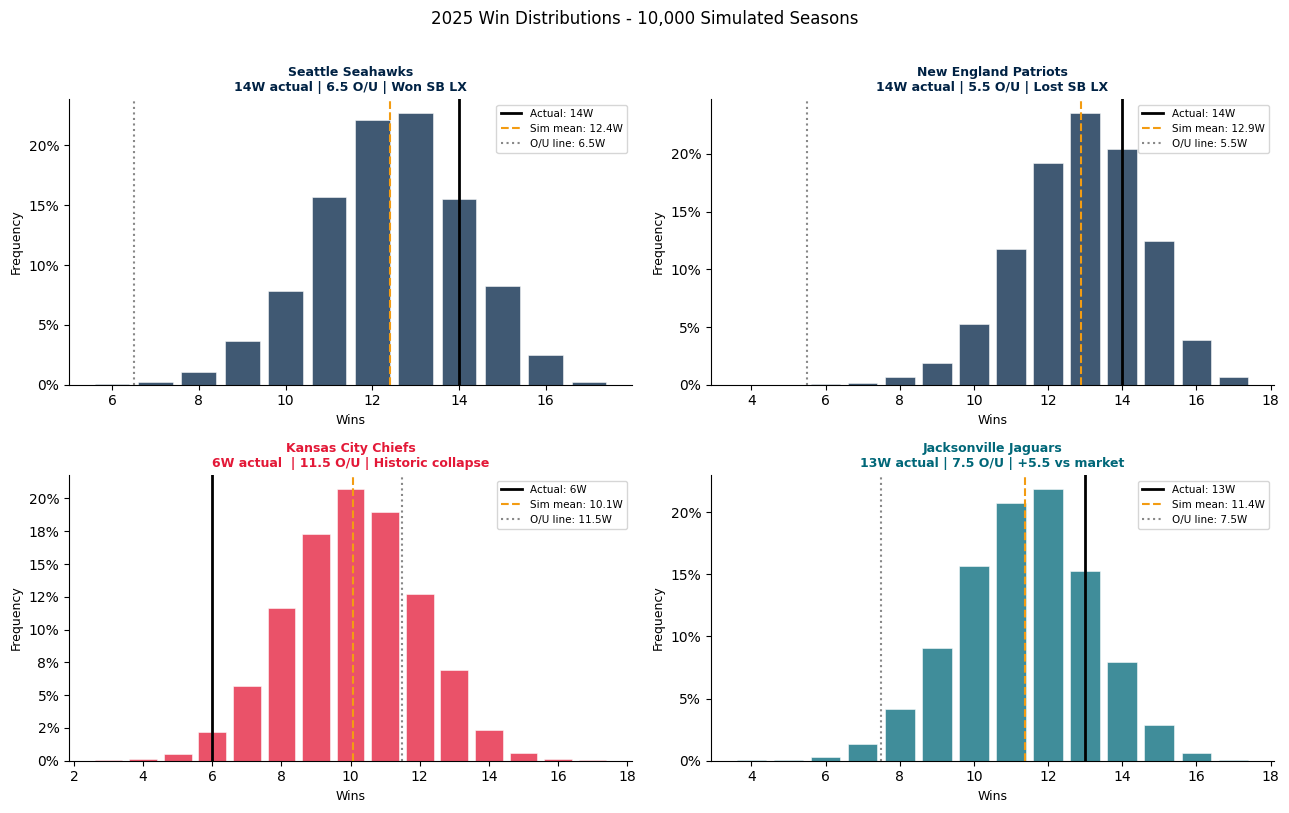

In [8]:
highlight = [
    ("Seattle Seahawks",       "#002244", "14W actual | 6.5 O/U | Won SB LX"),
    ("New England Patriots",   "#002244", "14W actual | 5.5 O/U | Lost SB LX"),
    ("Kansas City Chiefs",     "#E31837", "6W actual  | 11.5 O/U | Historic collapse"),
    ("Jacksonville Jaguars",   "#006778", "13W actual | 7.5 O/U | +5.5 vs market"),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for ax, (team, color, note) in zip(axes, highlight):
    wins   = sim_wins[team]
    actual = int(df[df.team == team]["actual_wins"].values[0])
    ou     = df[df.team == team]["ou_line"].values[0]
    wc     = Counter(wins)
    x = sorted(wc.keys())
    y = [wc[w] / N_SIMS for w in x]

    ax.bar(x, y, color=color, alpha=0.75, edgecolor="white", linewidth=0.5)
    ax.axvline(actual, color="black",   linestyle="-",  linewidth=2.0, label=f"Actual: {actual}W")
    ax.axvline(np.mean(wins), color="#f39c12", linestyle="--", linewidth=1.5,
               label=f"Sim mean: {np.mean(wins):.1f}W")
    ax.axvline(ou, color="#888888", linestyle=":", linewidth=1.5, label=f"O/U line: {ou}W")

    ax.set_title(f"{team}\n{note}", fontsize=9, fontweight="bold", color=color)
    ax.set_xlabel("Wins", fontsize=9)
    ax.set_ylabel("Frequency", fontsize=9)
    ax.legend(fontsize=7.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

plt.suptitle(f"2025 Win Distributions - {N_SIMS:,} Simulated Seasons", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("nfl_surprise_teams_2025.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Model calibration

Does PPG margin predict actual win totals? And how does it compare to the preseason betting market?


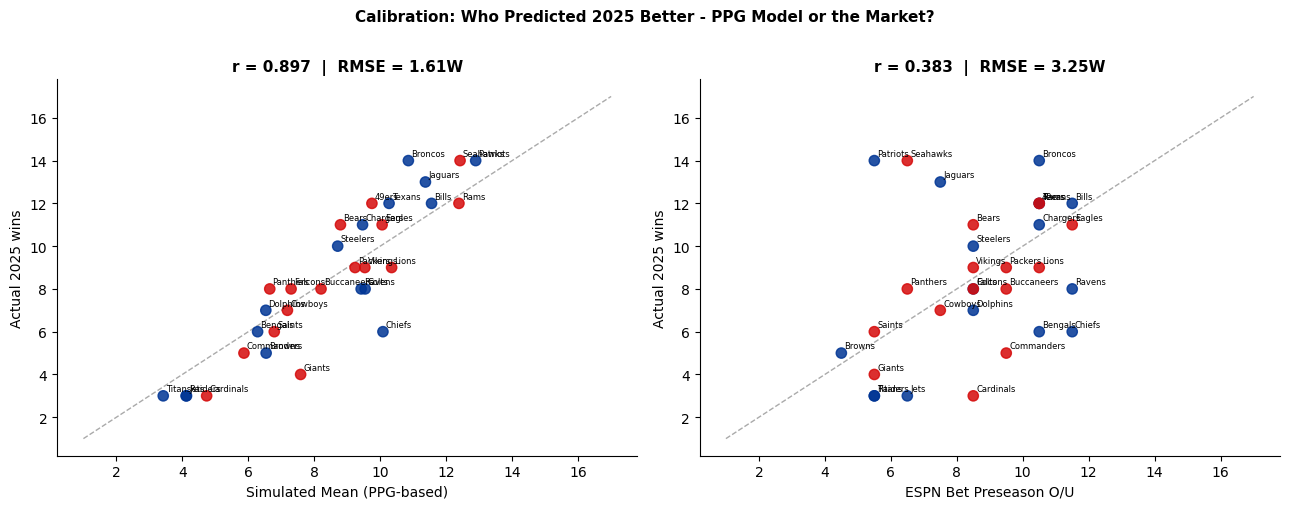

PPG model:   r = 0.897, RMSE = 1.61 wins
Market O/U:  r = 0.383, RMSE = 3.25 wins

The PPG model was more accurate than the preseason market this season.
(Note: PPG model uses final-season data; market only had preseason info.)


In [9]:
from scipy.stats import pearsonr

actual    = df_summary["actual_wins"].values.astype(float)
sim_pred  = df_summary["sim_mean"].values
market    = df_summary["ou_line"].values

r_sim, _    = pearsonr(actual, sim_pred)
r_market, _ = pearsonr(actual, market)
rmse_sim    = np.sqrt(np.mean((actual - sim_pred)**2))
rmse_market = np.sqrt(np.mean((actual - market)**2))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (pred, label, r, rmse, col) in zip(axes, [
    (sim_pred, "Simulated Mean (PPG-based)", r_sim,    rmse_sim,    "#003594"),
    (market,   "ESPN Bet Preseason O/U",     r_market, rmse_market, "#f39c12"),
]):
    colors3 = ["#003594" if c == "AFC" else "#D50A0A" for c in df_summary["conference"]]
    ax.scatter(pred, actual, c=colors3, s=55, alpha=0.85, zorder=3)
    lims = [1, 17]
    ax.plot(lims, lims, color="#aaaaaa", linestyle="--", linewidth=1)
    for _, row in df_summary.iterrows():
        p_val = row.sim_mean if "Sim" in label else row.ou_line
        ax.annotate(row.team.split()[-1], (p_val, row.actual_wins),
                    fontsize=6, ha="left", va="bottom",
                    xytext=(2, 2), textcoords="offset points")
    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel("Actual 2025 wins", fontsize=10)
    ax.set_title(f"r = {r:.3f}  |  RMSE = {rmse:.2f}W", fontsize=11, fontweight="bold")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("Calibration: Who Predicted 2025 Better - PPG Model or the Market?",
             fontsize=11, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("nfl_calibration_2025.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"PPG model:   r = {r_sim:.3f}, RMSE = {rmse_sim:.2f} wins")
print(f"Market O/U:  r = {r_market:.3f}, RMSE = {rmse_market:.2f} wins")
print()
if rmse_sim < rmse_market:
    print("The PPG model was more accurate than the preseason market this season.")
else:
    print("The preseason market was more accurate than the PPG model this season.")
print("(Note: PPG model uses final-season data; market only had preseason info.)")


## 9. Summary statistics


In [10]:
print("=" * 80)
print(f"  2025 NFL Win Total Simulation - {N_SIMS:,} seasons")
print("=" * 80)
print(f"  {'Team':<28} {'Act':>4} {'O/U':>5} {'MktD':>5} {'SimM':>6} {'Std':>5} {'P(10+)':>7}")
print("-" * 80)

df_print = df_summary.sort_values("sim_mean", ascending=False)
for _, row in df_print.iterrows():
    diff = row.actual_wins - row.ou_line
    flag = " **" if abs(diff) >= 5 else ("  *" if abs(diff) >= 3 else "   ")
    mkt  = f"+{diff:.1f}" if diff >= 0 else f"{diff:.1f}"
    print(f"  {row.team:<28} {int(row.actual_wins):>4} {row.ou_line:>5.1f} "
          f"{mkt:>5} {row.sim_mean:>6.1f} {row.sim_std:>5.1f} {row.p_10plus:>7.0%}{flag}")

print()
print("  ** = 5+ wins from preseason line    * = 3+ wins from preseason line")
print()

overperf = df_summary.copy()
overperf["diff"] = overperf["actual_wins"] - overperf["ou_line"]
print("  Biggest overs (actual >> O/U line):")
for _, row in overperf.nlargest(5, "diff").iterrows():
    print(f"    {row.team:<28} O/U: {row.ou_line:.1f}  Actual: {int(row.actual_wins)}  "
          f"({row['diff']:+.1f}W)")
print()
print("  Biggest unders (actual << O/U line):")
for _, row in overperf.nsmallest(5, "diff").iterrows():
    print(f"    {row.team:<28} O/U: {row.ou_line:.1f}  Actual: {int(row.actual_wins)}  "
          f"({row['diff']:+.1f}W)")


  2025 NFL Win Total Simulation - 10,000 seasons
  Team                          Act   O/U  MktD   SimM   Std  P(10+)
--------------------------------------------------------------------------------
  New England Patriots           14   5.5  +8.5   12.9   1.7     97% **
  Seattle Seahawks               14   6.5  +7.5   12.4   1.7     95% **
  Los Angeles Rams               12  10.5  +1.5   12.4   1.7     95%   
  Buffalo Bills                  12  11.5  +0.5   11.6   1.8     88%   
  Jacksonville Jaguars           13   7.5  +5.5   11.4   1.8     85% **
  Denver Broncos                 14  10.5  +3.5   10.9   1.9     77%  *
  Detroit Lions                   9  10.5  -1.5   10.3   1.9     67%   
  Houston Texans                 12  10.5  +1.5   10.3   1.9     66%   
  Kansas City Chiefs              6  11.5  -5.5   10.1   1.9     62% **
  Philadelphia Eagles            11  11.5  -0.5   10.1   1.9     62%   
  San Francisco 49ers            12  10.5  +1.5    9.7   1.8     55%   
  Indiana

## 10. The 2025 story in numbers

The 2025 NFL season was one of the most chaotic on record for preseason expectations:

- **Seattle Seahawks** went 14-3 and won Super Bowl LX at 60-1 preseason odds. Their O/U was 6.5.
- **New England Patriots** went 14-3 and reached the Super Bowl at 80-1 preseason odds. Their O/U was 5.5 — making them the biggest over-performer on the board.
- **Kansas City Chiefs** went 6-11 despite an 11.5 O/U, a -5.5 miss and the worst collapse by a preseason favorite in recent memory.
- **Denver Broncos** also went 14-3, giving the AFC West three 10-win teams alongside the Chargers at 11-6 — but KC finished at the bottom of the same division.
- Three teams (SEA, NE, DEN) tied for the best record in football at 14-3.

The PPG-based simulation, using final-season stats, correctly identifies Seattle and New England as dominant teams. The preseason market had no way to know this — both were priced as rebuilding projects.



---
*Stats sourced from champsorchumps.us/summary/nfl/2025. Preseason O/U lines from ESPN Bet (March 2025). Seattle Seahawks won Super Bowl LX over New England Patriots, 29-13.*
